## Задание 1
#### а) Какие подгруппы товаров наиболее часто покупают за все время продаж (минимум 4 группы)?
#### б) Какие подгруппы товаров наиболее часто покупают за последние два года (минимум 4 группы)?
#### в) Какие подгруппы товаров наиболее часто покупают за последний год(минимум 4 группы)?

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data.csv")
df.head()

,ID,Order Date,Class,Region,Sub-Category,Sales
0,646,30/12/2018,Стандарт,Урал,Appliances,"37229,08"
1,907,30/12/2018,Стандарт,Владивосток,Bookcases,"20994,61"
2,908,30/12/2018,Стандарт,Владивосток,Phones,"42133,86"
3,909,30/12/2018,Стандарт,Владивосток,Binders,10612
4,1297,30/12/2018,Стандарт,Калиниград,Binders,"28781,13"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ID            9800 non-null   int64 
 1   Order Date    9800 non-null   object
 2   Class         9800 non-null   object
 3   Region        9800 non-null   object
 4   Sub-Category  9800 non-null   object
 5   Sales         9800 non-null   object
dtypes: int64(1), object(5)
memory usage: 459.5+ KB


In [4]:
# Преобразую колонку с датой в формат datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [5]:
dmax, dmin = df['Order Date'].max(), df['Order Date'].min()
print(f"Самая старая дата {dmin}, а самая новая дата {dmax}")

Самая старая дата 2015-01-03 00:00:00, а самая новая дата 2018-12-30 00:00:00


In [6]:
df["Sub-Category"].unique()

array(['Appliances', 'Bookcases', 'Phones', 'Binders', 'Fasteners',
       'Chairs', 'Paper', 'Furnishings', 'Art', 'Storage', 'Labels',
       'Accessories', 'Tables', 'Supplies', 'Machines', 'Copiers',
       'Envelopes'], dtype=object)

#### Поиск популярных подгрупп товаров за все время

In [7]:
# Считаю количество покупок по подгруппам
top_subcat = df['Sub-Category'].value_counts().head(4)
print(top_subcat)

Binders        1492
Paper          1338
Furnishings     931
Phones          876
Name: Sub-Category, dtype: int64


#### Популярные подгруппы за последние два года

По сути ответа здесь нет. За последние 2 года нет данных.
Странно, что условие не актуализировали, так как по факту последняя самая свежая Order Date здесь 2018-12-30

In [8]:
# Фильтрую за последние два года в базе данных
two_years_ago = pd.Timestamp.now() - pd.DateOffset(years=8)
df_last_yrs = df[df['Order Date'] >= two_years_ago]

# по подгруппам
top_sub_2years = df_last_yrs['Sub-Category'].value_counts().head(4)
print(top_sub_2years)


Binders        1040
Paper           933
Furnishings     642
Phones          601
Name: Sub-Category, dtype: int64


#### Популярные подгруппы за последний год

In [9]:
# Фильтрую за последний год в бд
one_year_ago = pd.Timestamp.now() - pd.DateOffset(years=7)
df_last_year = df[df['Order Date'] >= one_year_ago]

# по подгруппам
top_sub_1year = df_last_year['Sub-Category'].value_counts().head(4)
print(top_sub_1year)


Binders        665
Paper          583
Furnishings    419
Storage        367
Name: Sub-Category, dtype: int64


### Вывод таков, что первая тройка товаров держится популярной все время и стабильно в разрезе лет.
Однако в последний год набирает популярность групп товаров телефонов

#### Задание 2
 Построить boxplot («Ящик с усами») на основе продаж (Sales). Найти мажоритарную черту (т.е. избавиться от аномалий и представить четкую картину распределения величин).
 Можно использовать правило трех сигм. Однако любые другие решения приветствуются.


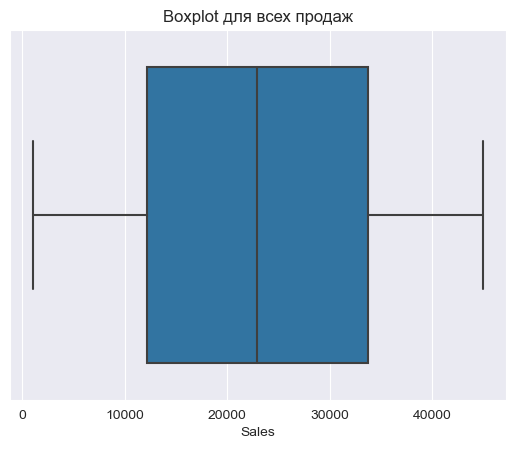

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Sales'] = df['Sales'].str.replace(',', '.').astype(float)
sns.boxplot(x=df['Sales'])
plt.title("Boxplot для всех продаж")
plt.show()


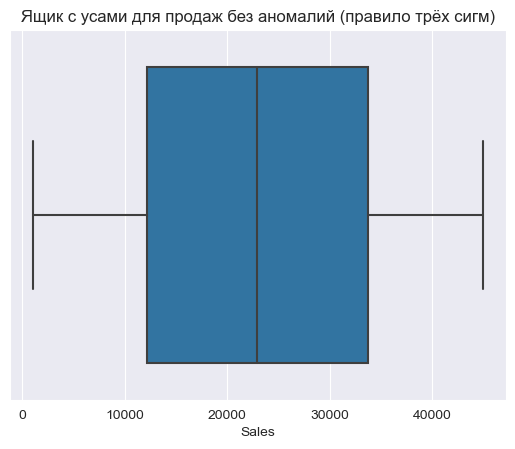

Правило трёх сигм: Убрано 0 выбросов, что составляет 0.00%


In [11]:
# до фильтра
total = len(df)

mean_sales = df['Sales'].mean()
std_sales = df['Sales'].std()

# Применение трёх сигм
df_filtered = df[(df['Sales'] >= mean_sales - 3 * std_sales) & (df['Sales'] <= mean_sales + 3 * std_sales)]

# после фильтра
filt = len(df_filtered)

sns.boxplot(x=df_filtered['Sales'])
plt.title("Ящик с усами для продаж без аномалий (правило трёх сигм)")
plt.show()

# Количество и процент удаленных выбросов
removed_sigma = total - filt
p_removed_sigma = (removed_sigma / total) * 100

print(f"Правило трёх сигм: Убрано {removed_sigma} выбросов, что составляет {p_removed_sigma:.2f}%")

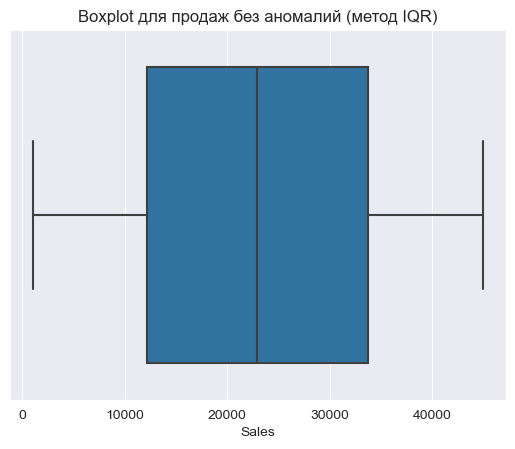

IQR: Убрано 0 выбросов, что составляет 0.00%


In [12]:
# Вычисление квартилей и IQR
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

# Определение границ для фильтрации
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фильтр
df_iqr_filtered = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]

# кол-во записей после фильтра
filter_iqr = len(df_iqr_filtered)

# Построение ящика для очищенных данных
sns.boxplot(x=df_iqr_filtered['Sales'])
plt.title("Boxplot для продаж без аномалий (метод IQR)")
plt.show()

# Колво и процент удаленных выбросов
removed_iqr = total - filter_iqr
p_removed_iqr = (removed_iqr / total) * 100

print(f"IQR: Убрано {removed_iqr} выбросов, что составляет {p_removed_iqr:.2f}%")


### Вывод таков, что выбросов вообще нет. Это странно, но это факт. Обычно на работе я использовал метод IQR и процент выбросов колебался от 5 до 15.

`pd.qcut` разделяет значения на равные квантильные группы
Он гарантирует, что каждая группа будет иметь +-одинаковое количество записей

In [19]:
df['Sale_group'] = pd.qcut(df['Sales'], q=3, labels=['Маленькие продажи', 'Средние продажи', 'Большие продажи'])
df['Sale_group']

0         Большие продажи
1         Средние продажи
2         Большие продажи
3       Маленькие продажи
4         Средние продажи
              ...        
9795    Маленькие продажи
9796    Маленькие продажи
9797      Средние продажи
9798    Маленькие продажи
9799    Маленькие продажи
Name: Sale_group, Length: 9800, dtype: category
Categories (3, object): ['Маленькие продажи' < 'Средние продажи' < 'Большие продажи']

Я группирую данные по регионам и созданным группам продаж, подсчитывая:
> Общие продажи как общая сумма продаж в каждой группе.
> Средние продажи как средняя величина продаж в каждой группе.
> И количество продаж как колво покупок, которое попадает в каждую группу.

In [20]:
grouped_data = df.groupby(['Region', 'Sale_group']).agg(
    total_sales=('Sales', 'sum'),
    avg_sales=('Sales', 'mean'),
    count_sales=('Sales', 'count')
).reset_index()

print(grouped_data)

         Region         Sale_group   total_sales     avg_sales  count_sales
0   Владивосток  Маленькие продажи  7.830757e+06   8286.515222          945
1   Владивосток    Средние продажи  2.030969e+07  22974.767613          884
2   Владивосток    Большие продажи  3.581224e+07  37460.497312          956
3    Калиниград  Маленькие продажи  8.873517e+06   8548.667623         1038
4    Калиниград    Средние продажи  2.515241e+07  23012.267795         1093
5    Калиниград    Большие продажи  3.790437e+07  37566.277532         1009
6        Москва  Маленькие продажи  4.256534e+06   8217.246938          518
7        Москва    Средние продажи  1.225589e+07  22865.475168          536
8        Москва    Большие продажи  2.037922e+07  37461.806820          544
9          Урал  Маленькие продажи  6.419256e+06   8380.229930          766
10         Урал    Средние продажи  1.718101e+07  22816.742855          753
11         Урал    Большие продажи  2.825832e+07  37280.111082          758


#### Регион с максимальными продажами

In [21]:
most_profit = grouped_data.loc[grouped_data['total_sales'].idxmax()]
print(f"Наиболее прибыльная группа: {most_profit}")

Наиболее прибыльная группа: Region              Калиниград
Sale_group     Большие продажи
total_sales        37904374.03
avg_sales         37566.277532
count_sales               1009
Name: 5, dtype: object


#### Группы с наибольшей суммой продаж в каждом регионе

In [22]:
profit_by_region = grouped_data.loc[grouped_data.groupby('Region')['total_sales'].idxmax()]

print("Группа с наибольшей суммой продаж в каждом регионе:")
print(profit_by_region)

Группа с наибольшей суммой продаж в каждом регионе:
         Region       Sale_group  total_sales     avg_sales  count_sales
2   Владивосток  Большие продажи  35812235.43  37460.497312          956
5    Калиниград  Большие продажи  37904374.03  37566.277532         1009
8        Москва  Большие продажи  20379222.91  37461.806820          544
11         Урал  Большие продажи  28258324.20  37280.111082          758


#### Наименее прибыльные регионы

In [23]:
region_sales = df.groupby('Region').agg(total_sales=('Sales', 'sum')).reset_index()

# по возрастанию, чтобы найти наименее прибыльные регионы
least_profit = region_sales.sort_values(by='total_sales', ascending=True)

print("Наименее прибыльные регионы:")
print(least_profit)

Наименее прибыльные регионы:
        Region   total_sales
2       Москва  3.689165e+07
3         Урал  5.185859e+07
0  Владивосток  6.395269e+07
1   Калиниград  7.193030e+07


#### наиболее часто продаваемые группы продаж по каждому региону

In [24]:
# Группировка по регионам и группам продаж, подсчет количества продаж в каждой группе
group_sales_count = df.groupby(['Region', 'Sale_group']).agg(count_sales=('Sales', 'count')).reset_index()

most_freq = group_sales_count.loc[group_sales_count.groupby('Region')['count_sales'].idxmax()]

print("\nНаиболее часто продаваемые группы продаж по каждому региону:")
print(most_freq)


Наиболее часто продаваемые группы продаж по каждому региону:
        Region         Sale_group  count_sales
2  Владивосток    Большие продажи          956
4   Калиниград    Средние продажи         1093
8       Москва    Большие продажи          544
9         Урал  Маленькие продажи          766


### Выводы представлены непосредственно в выводе данных